# Isolation Forest — Hyperparameter Search (AnomX)

This notebook searches over Isolation Forest hyperparameters (`n_estimators`, `contamination`, `max_samples`, `max_features`) on the engineered feature set from Week 4, and scores each combination against the known `is_anomalous` label using **ROC-AUC** and **Average Precision**.

> Note: Isolation Forest itself is trained *unsupervised* (it never sees `is_anomalous` during `.fit()`). We only use the label here to evaluate which hyperparameters produce the best-separated anomaly scores — this is safe because our dataset is synthetic and fully labeled. In a real deployment you would tune `contamination` using domain knowledge / expected fraud rate instead.

**Output of this notebook:** a ranked table of hyperparameter combinations + the best config to drop into `configs/config.yaml`.


In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))  # so `from src...` imports work if run from a notebooks/ folder

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
from pathlib import Path
import yaml

PROJECT_ROOT = Path.cwd().parent



## 1. Load config + processed features

In [3]:
with open(PROJECT_ROOT / "configs" / "data.yaml", "r") as f:
    config = yaml.safe_load(f)

PROCESSED_PATH =  PROJECT_ROOT / config["data"]["processed_path"]
print("Loading:", PROCESSED_PATH)

df = pd.read_csv(PROCESSED_PATH)
print("Shape:", df.shape)
df.head()


Loading: c:\Users\Nikhil\Desktop\anomx\final_code\data\processed\features.csv
Shape: (50000, 58)


,event_id,user_id,event_type,timestamp,hour_of_day,day_of_week,is_weekend,is_anomalous,anomaly_type,ip_address,country,device,login_success,failed_attempts,timezone_gap_hours,instrument,lot_size,trade_volume,pnl,margin_used,trade_duration_seconds,trade_volume_vs_baseline,is_night_trade,amount,method,is_immediate_withdrawal,session_duration_mins,page_clicks,click_rate_per_min,kyc_change_type,account_age_days,time_since_last_event_sec,time_since_last_login_sec,time_since_last_deposit_sec,roll_5_trade_vol_mean,roll_5_trade_vol_std,roll_5_pnl_mean,roll_10_trade_vol_mean,roll_10_trade_vol_std,roll_10_pnl_mean,roll_30_trade_vol_mean,roll_30_trade_vol_std,roll_30_pnl_mean,roll_5_click_rate_mean,roll_10_click_rate_mean,roll_30_click_rate_mean,burst_count_5min,burst_count_30min,unique_ips_last_10_logins,unique_countries_last_10_logins,unique_devices_last_10_logins,rolling_failed_attempts_5,roll_5_deposit_sum,withdrawal_to_deposit_ratio,trade_vol_zscore,pnl_zscore,amount_zscore,session_duration_zscore
0,EVT_304595,USER_0000,trade,2024-01-01 01:04:36,1,0,0,1,wash_trader,NaN,NaN,NaN,NaN,NaN,NaN,USDCHF,0.08,9814.32,151.70,777.05,1425.0,0.827,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,325,0.0,0.0,0.0,9814.320000,0.000000,151.700,9814.320000,0.000000,151.700,9814.320000,0.000000,151.700,0.0,0.0,0.0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,-0.565431,-0.423405,0.000000,0.0
1,EVT_637273,USER_0000,trade,2024-01-01 16:01:51,16,0,0,1,wash_trader,NaN,NaN,NaN,NaN,NaN,NaN,USDCHF,1.34,8520.61,50.15,3724.68,3270.0,0.718,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,325,53835.0,0.0,0.0,9167.465000,914.791114,100.925,9167.465000,914.791114,100.925,9167.465000,914.791114,100.925,0.0,0.0,0.0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,-0.582884,-0.484037,0.000000,0.0
2,EVT_749975,USER_0000,trade,2024-01-02 14:09:59,14,1,0,1,wash_trader,NaN,NaN,NaN,NaN,NaN,NaN,USDCHF,0.49,12325.36,-81.31,3358.94,1586.0,1.039,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,326,79688.0,0.0,0.0,10220.096667,1934.559812,40.180,10220.096667,1934.559812,40.180,10220.096667,1934.559812,40.180,0.0,0.0,0.0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,-0.531557,-0.562527,0.000000,0.0
3,EVT_969821,USER_0000,login,2024-01-03 04:47:38,4,2,0,1,wash_trader,172.16.4.1,SG,safari_mac,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,327,52659.0,0.0,0.0,0.000000,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000,0.0,0.0,0.0,1,1,1.0,1.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0
4,EVT_299345,USER_0000,withdrawal,2024-01-04 08:32:44,8,3,0,1,wash_trader,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1414.77,crypto,0.0,NaN,NaN,NaN,NaN,328,99906.0,99906.0,0.0,0.000000,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000,0.0,0.0,0.0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,-1.180471,0.0


## 2. Feature columns

Same list used in `src/models/isolation_forest.py` — kept in sync so whatever hyperparameters
you pick here plug straight into the real training script without a feature mismatch.


In [4]:
FEATURE_COLS = [
    # Raw behavioral signals
    "hour_of_day", "day_of_week", "is_weekend",
    "login_success", "failed_attempts", "timezone_gap_hours",
    "lot_size", "trade_volume", "pnl", "margin_used", "trade_duration_seconds",
    "trade_volume_vs_baseline", "is_night_trade",
    "amount", "is_immediate_withdrawal",
    "session_duration_mins", "page_clicks", "click_rate_per_min",
    "account_age_days",
    # Engineered features
    "time_since_last_event_sec", "time_since_last_login_sec",
    "time_since_last_deposit_sec",
    "roll_5_trade_vol_mean",  "roll_5_trade_vol_std",  "roll_5_pnl_mean",
    "roll_10_trade_vol_mean", "roll_10_trade_vol_std", "roll_10_pnl_mean",
    "roll_30_trade_vol_mean", "roll_30_trade_vol_std", "roll_30_pnl_mean",
    "roll_5_click_rate_mean", "roll_10_click_rate_mean", "roll_30_click_rate_mean",
    "burst_count_5min", "burst_count_30min",
    "unique_ips_last_10_logins", "unique_countries_last_10_logins",
    "unique_devices_last_10_logins", "rolling_failed_attempts_5",
    "roll_5_deposit_sum", "withdrawal_to_deposit_ratio",
    "trade_vol_zscore", "pnl_zscore", "amount_zscore", "session_duration_zscore",
]

missing = [c for c in FEATURE_COLS if c not in df.columns]
assert not missing, f"Missing expected feature columns: {missing}"

df[FEATURE_COLS] = df[FEATURE_COLS].fillna(0)
X = df[FEATURE_COLS].values.astype(np.float32)
y = df["is_anomalous"].values

print("X:", X.shape, " | anomaly rate:", y.mean().round(4))


X: (50000, 46)  | anomaly rate: 0.053


## 3. Sanity check: what contamination should even be in range?

`contamination` tells Isolation Forest what fraction of the data to treat as outliers.
Your synthetic generator was built with a target `anomaly_fraction` in `config.yaml` — that's a
good center point for the search grid, but real anomaly *events* (not users) may differ from the
per-user injection rate, so we search a band around it.


In [5]:
target_anomaly_fraction = config["data"].get("anomaly_fraction", None)
actual_event_anomaly_rate = y.mean()

print(f"Configured anomaly_fraction (per user): {target_anomaly_fraction}")
print(f"Actual event-level anomaly rate:        {actual_event_anomaly_rate:.4f}")


Configured anomaly_fraction (per user): 0.05
Actual event-level anomaly rate:        0.0530


## 4. Define the hyperparameter grid

In [6]:
contamination_values = sorted(set([
    round(max(actual_event_anomaly_rate * 0.25, 0.005), 3),
    round(max(actual_event_anomaly_rate * 0.50, 0.01), 3),
    round(actual_event_anomaly_rate * 0.75, 3),
    round(actual_event_anomaly_rate, 3),
    round(min(actual_event_anomaly_rate * 1.25, 0.5), 3),
    round(min(actual_event_anomaly_rate * 1.50, 0.5), 3),
    round(min(actual_event_anomaly_rate * 2.00, 0.5), 3),
]))

param_grid = {
    "n_estimators":  [100, 200, 300],
    # "contamination": sorted(set([
    #     round(max(actual_event_anomaly_rate * 0.5, 0.01), 3),
    #     round(actual_event_anomaly_rate, 3),
    #     round(min(actual_event_anomaly_rate * 1.5, 0.5), 3),
    # ])),
    "contamination": contamination_values,
    "max_samples":   [256, 512, "auto"],
    "max_features":  [0.5, 0.7, 0.9, 1.0],
}

combos = list(product(
    param_grid["n_estimators"],
    param_grid["contamination"],
    param_grid["max_samples"],
    param_grid["max_features"],
))
print(f"Total combinations to try: {len(combos)}")
param_grid


Total combinations to try: 252


{'n_estimators': [100, 200, 300],
 'contamination': [np.float64(0.013),
  np.float64(0.026),
  np.float64(0.04),
  np.float64(0.053),
  np.float64(0.066),
  np.float64(0.08),
  np.float64(0.106)],
 'max_samples': [256, 512, 'auto'],
 'max_features': [0.5, 0.7, 0.9, 1.0]}

## 5. Run the search

For each combination we:
1. Build a `StandardScaler -> IsolationForest` pipeline (matches production code)
2. Fit on the full feature matrix (unsupervised — no `y` passed in)
3. Get `decision_function` scores, negate so higher = more anomalous
4. Score against `y` with ROC-AUC and Average Precision

This can take a few minutes depending on grid size — feel free to shrink `param_grid` above for a
quick pass, then widen it around the best region.


In [7]:
results = []

RANDOM_STATE = config["model"]["isolation_forest"].get("random_state", 42)

for n_estimators, contamination, max_samples, max_features in combos:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("iforest", IsolationForest(
            n_estimators  = n_estimators,
            contamination = contamination,
            max_samples   = max_samples,
            max_features  = max_features,
            random_state  = RANDOM_STATE,
            n_jobs        = -1,
        )),
    ])

    pipe.fit(X)

    raw_scores     = pipe.decision_function(X)   # negative = more anomalous
    anomaly_scores = -raw_scores                 # higher = more anomalous
    preds          = pipe.predict(X)             # -1 anomaly / +1 normal
    labels         = (preds == -1).astype(int)

    auc = roc_auc_score(y, anomaly_scores)
    ap  = average_precision_score(y, anomaly_scores)

    flagged_rate = labels.mean()

    results.append({
        "n_estimators": n_estimators,
        "contamination": contamination,
        "max_samples": max_samples,
        "max_features": max_features,
        "roc_auc": auc,
        "avg_precision": ap,
        "flagged_rate": flagged_rate,
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
print(f"Done. {len(results_df)} combinations evaluated.")
results_df.head(15)


Done. 252 combinations evaluated.


,n_estimators,contamination,max_samples,max_features,roc_auc,avg_precision,flagged_rate
0,100,0.013,512,1.0,0.529509,0.135793,0.013
1,100,0.026,512,1.0,0.529509,0.135793,0.026
2,100,0.053,512,1.0,0.529509,0.135793,0.053
3,100,0.040,512,1.0,0.529509,0.135793,0.040
4,100,0.066,512,1.0,0.529509,0.135793,0.066
5,100,0.080,512,1.0,0.529509,0.135793,0.080
6,100,0.106,512,1.0,0.529509,0.135793,0.106
7,300,0.066,512,1.0,0.527456,0.143830,0.066
8,300,0.106,512,1.0,0.527456,0.143830,0.106
9,300,0.053,512,1.0,0.527456,0.143830,0.053


## 6. Best combination(s)

In [8]:
best_by_auc = results_df.sort_values("roc_auc", ascending=False).iloc[0]
best_by_ap  = results_df.sort_values("avg_precision", ascending=False).iloc[0]

print("Best by ROC-AUC:")
print(best_by_auc, end="\n\n")

print("Best by Average Precision:")
print(best_by_ap)


Best by ROC-AUC:
n_estimators          100
contamination       0.013
max_samples           512
max_features          1.0
roc_auc          0.529509
avg_precision    0.135793
flagged_rate        0.013
Name: 0, dtype: object

Best by Average Precision:
n_estimators          100
contamination       0.013
max_samples           512
max_features          0.5
roc_auc          0.525523
avg_precision    0.144756
flagged_rate        0.013
Name: 40, dtype: object


## 7. Visualize: how does each hyperparameter move ROC-AUC?

A few views to build intuition rather than just trusting one row of a table.


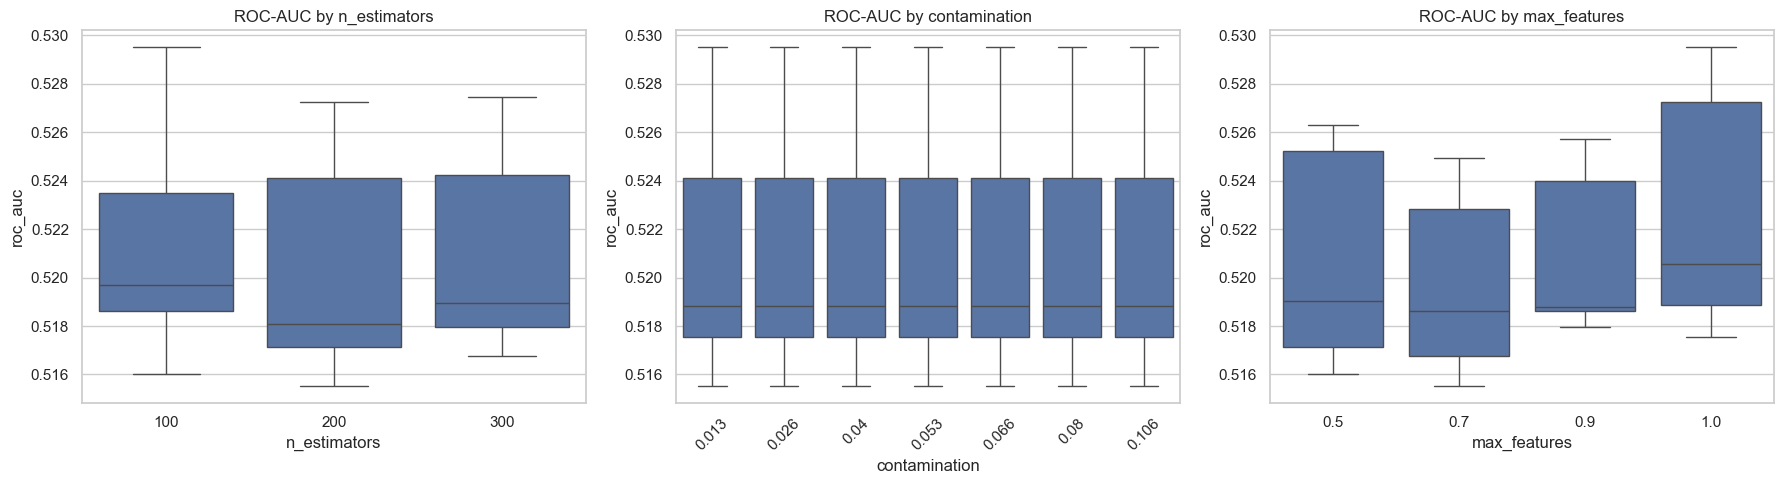

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=results_df, x="n_estimators", y="roc_auc", ax=axes[0])
axes[0].set_title("ROC-AUC by n_estimators")

sns.boxplot(data=results_df, x="contamination", y="roc_auc", ax=axes[1])
axes[1].set_title("ROC-AUC by contamination")
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=results_df, x="max_features", y="roc_auc", ax=axes[2])
axes[2].set_title("ROC-AUC by max_features")

plt.tight_layout()
plt.show()


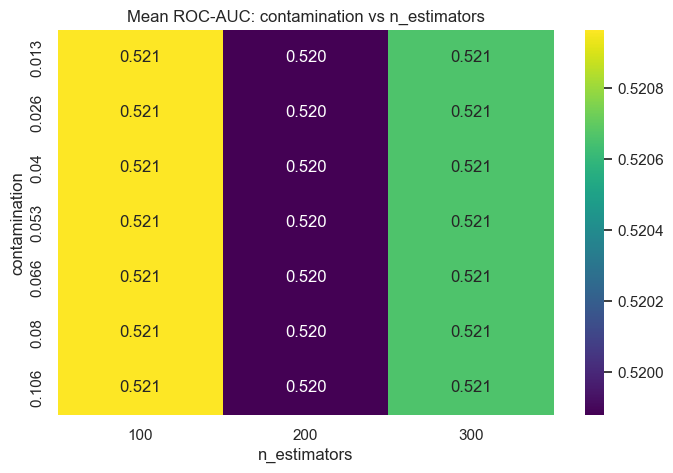

In [10]:
pivot = results_df.pivot_table(
    index="contamination", columns="n_estimators", values="roc_auc", aggfunc="mean"
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Mean ROC-AUC: contamination vs n_estimators")
plt.show()


## 8. Precision/Recall tradeoff at the chosen threshold

ROC-AUC and AP are threshold-free — but in production, Isolation Forest's `contamination`
parameter *is* the threshold (it decides what fraction gets flagged as -1). This cell shows the
confusion matrix for your best config so you can see the real precision/recall tradeoff, not just
the ranking metric.


              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97     47350
     Anomaly       0.36      0.09      0.14      2650

    accuracy                           0.94     50000
   macro avg       0.65      0.54      0.56     50000
weighted avg       0.92      0.94      0.93     50000



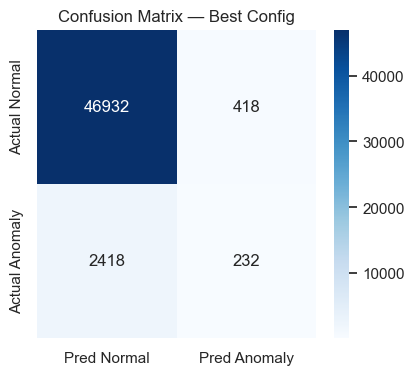

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

best = best_by_auc  # or swap to best_by_ap

best_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("iforest", IsolationForest(
        n_estimators  = int(best["n_estimators"]),
        contamination = best["contamination"],
        max_samples   = best["max_samples"],
        max_features  = best["max_features"],
        random_state  = RANDOM_STATE,
        n_jobs        = -1,
    )),
])
best_pipe.fit(X)
best_preds = (best_pipe.predict(X) == -1).astype(int)

print(classification_report(y, best_preds, target_names=["Normal", "Anomaly"], zero_division=0))

cm = confusion_matrix(y, best_preds)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Normal", "Pred Anomaly"],
            yticklabels=["Actual Normal", "Actual Anomaly"])
plt.title("Confusion Matrix — Best Config")
plt.show()


## 9. Final recommendation → paste into `configs/config.yaml`

Copy the printed block below into the `model.isolation_forest` section of your config so
`src/models/isolation_forest.py` picks it up automatically.


In [14]:
PROJECT_ROOT = Path.cwd().parent
model_yaml_path = PROJECT_ROOT / "configs" / "model.yaml"

with open(model_yaml_path, "r") as f:
    config = yaml.safe_load(f)  or {} 

config.setdefault("model", {})
config["model"]["isolation_forest"] = {
    "n_estimators": int(best_by_auc["n_estimators"]),
    "contamination": float(best_by_auc["contamination"]),
    "max_samples": best_by_auc["max_samples"],
    "max_features": float(best_by_auc["max_features"]),
    "random_state": RANDOM_STATE,
}

with open(model_yaml_path, "w") as f:
    yaml.dump(config, f, sort_keys=False)

print(f"✅ Updated {model_yaml_path}")

✅ Updated c:\Users\Nikhil\Desktop\anomx\final_code\configs\model.yaml


## 10. (Optional) Narrow the search

If the boxplots above show one region is clearly winning (e.g. all top rows share
`contamination ≈ 0.08` and `n_estimators ≥ 200`), re-run Section 4–6 with a tighter grid
centered there — e.g. `contamination: [0.06, 0.08, 0.10]`, `n_estimators: [200, 250, 300, 400]` —
for a finer-grained pick before writing your final config.
